<a href="https://colab.research.google.com/github/zurii-07/MindScope-AI-Powered-Mental-Wellness-Assistant/blob/Model-Training/Reddit_Mental_Health_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

01. Performing Exploratory Data Analysis

01. Dataset Shape: (5957, 4)

Data Types:
 text            object
title           object
target           int64
target_label    object
dtype: object

Missing Values:
 text            350
title             0
target            0
target_label      0
dtype: int64

Class Distribution:
 target_label
Depression              1202
Personality disorder    1201
Anxiety                 1188
Bipolar disorder        1185
Stress                  1181
Name: count, dtype: int64


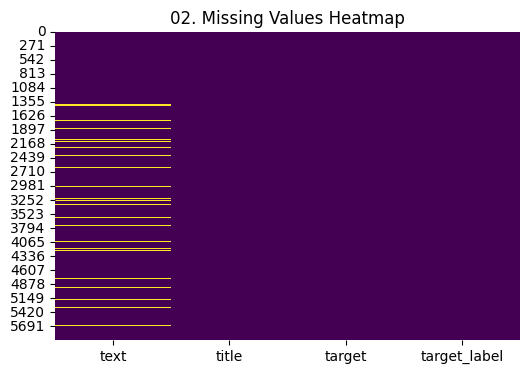

/tmp/ipython-input-3129976273.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target_label', order=df['target_label'].value_counts().index, palette='Set2')


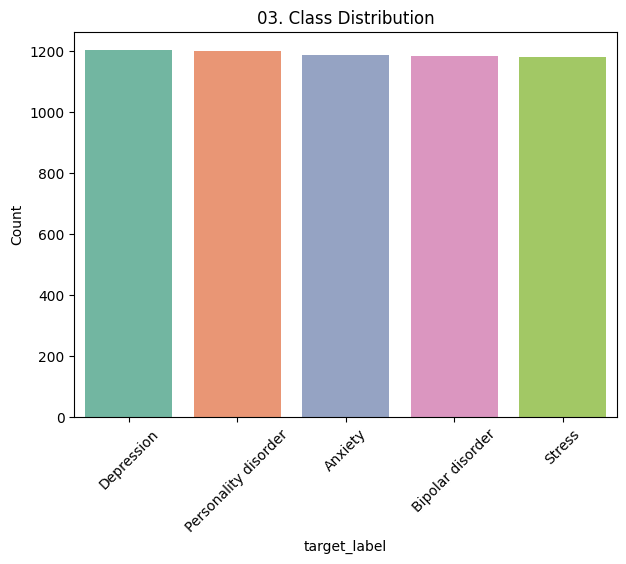

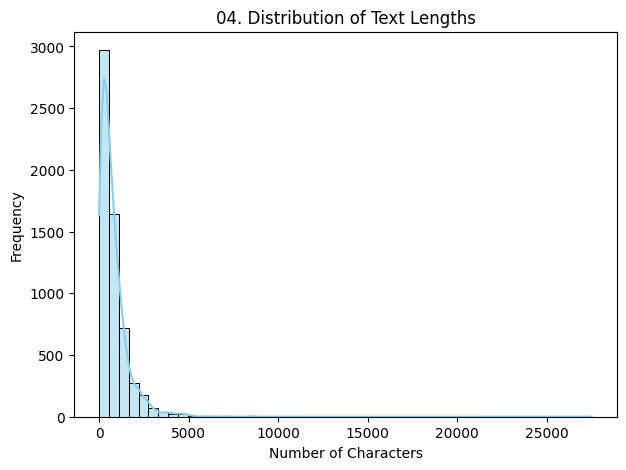

05. Potential outliers in text length: 349 rows


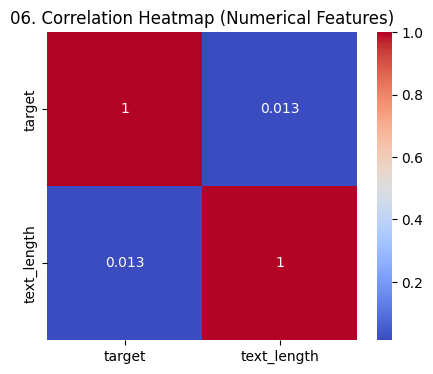

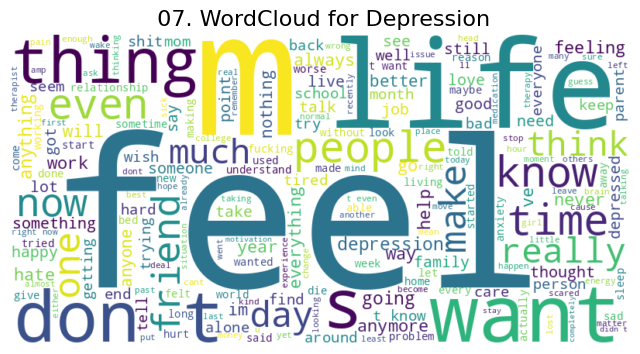

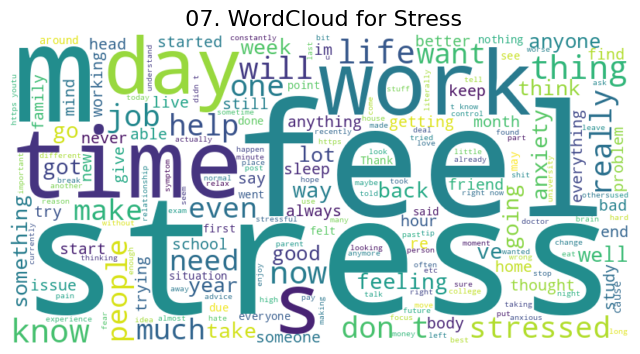

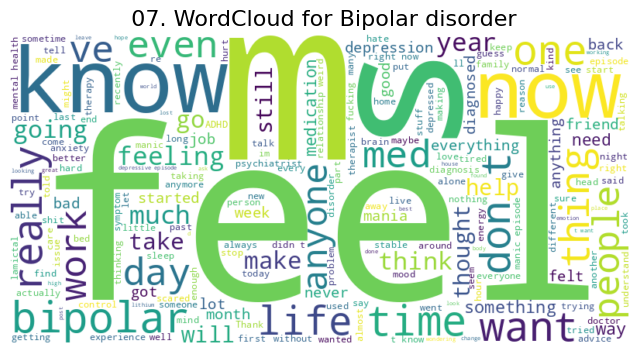

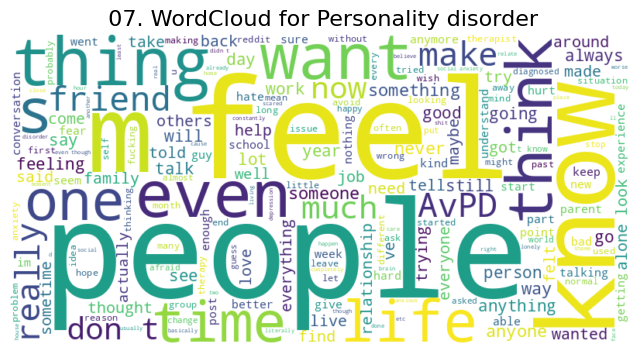

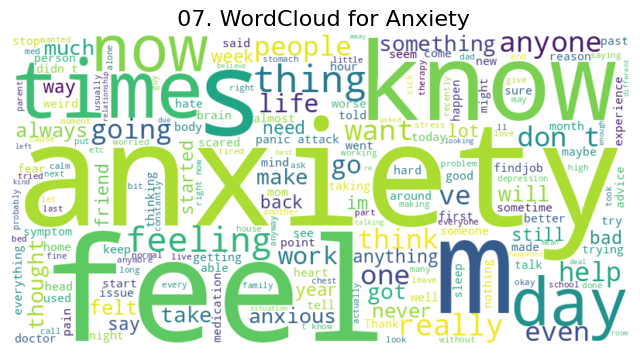


 08. Summary statistics for numerical features:
             target   text_length
count  5957.000000   5957.000000
mean      2.002182    787.263220
std       1.412252    879.580159
min       0.000000      1.000000
25%       1.000000    256.000000
50%       2.000000    553.000000
75%       3.000000   1035.000000
max       4.000000  27542.000000


,text,title,target,target_label,text_length
0,Welcome to /r/depression's check-in post - a p...,"Regular check-in post, with information about ...",1,Depression,2644
1,We understand that most people who reply immed...,Our most-broken and least-understood rules is ...,1,Depression,4792
2,Anyone else just miss physical touch? I crave ...,"I haven’t been touched, or even hugged, in so ...",1,Depression,58
3,I’m just so ashamed. Everyone and everything f...,Being Depressed is Embarrassing,1,Depression,905
4,I really need a friend. I don't even have a si...,I'm desperate for a friend and to feel loved b...,1,Depression,237


In [33]:
#Import libraries
import pandas as pd #for loading and manipulating tabular patient data
import numpy as np #for numerical operations - here for outlier detection using IQR
import matplotlib.pyplot as plt #for visualizations
import seaborn as sns
from wordcloud import WordCloud #generating word clouds for each target label

#Load the dataset
df = pd.read_csv('/content/drive/MyDrive/MindScope/datasets_to_be_cleaned/data_to_be_cleansed1.csv/data_to_be_cleansed.csv')

#Drop unnecessary index column if present
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True) #drops the redundant index column

# #Map target values to labels
target_mapping = {
    0: 'Stress',
    1: 'Depression',
    2: 'Bipolar disorder',
    3: 'Personality disorder',
    4: 'Anxiety'
}
df['target_label'] = df['target'].map(target_mapping)

#1. Dataset overview
print("01. Dataset Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nClass Distribution:\n", df['target_label'].value_counts())

#2. Missing value visualization
plt.figure(figsize=(6,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("02. Missing Values Heatmap")
plt.show()


#3. Class distribution
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='target_label', order=df['target_label'].value_counts().index, palette='Set2')
plt.title("03. Class Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


#4. Text length analysis
df['text_length'] = df['text'].astype(str).apply(len)
plt.figure(figsize=(7,5))
sns.histplot(df['text_length'], bins=50, kde=True, color='skyblue')
plt.title("04. Distribution of Text Lengths")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.show()


#5. Outlier detection in text length using IQR
q1, q3 = np.percentile(df['text_length'], [25, 75])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = df[(df['text_length'] < lower_bound) | (df['text_length'] > upper_bound)]
print(f"05. Potential outliers in text length: {len(outliers)} rows")


#6. Correlation heatmap for numerical features
num_cols = df.select_dtypes(include=np.number)
plt.figure(figsize=(5,4))
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm')
plt.title("06. Correlation Heatmap (Numerical Features)")
plt.show()


#7. WordCloud for each class
for label in df['target_label'].unique():
    text_combined = " ".join(df[df['target_label'] == label]['text'].dropna().astype(str))
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_combined)
    plt.figure(figsize=(8,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f" 07. WordCloud for {label}", fontsize=16)
    plt.show()

#8. Summary statistics
print("\n 08. Summary statistics for numerical features:\n", df.describe())
#print head
df.head()

Things to handle in pre-processing

In [34]:
#Showing record count where "text: is missing
print("\nNo. of rows to handle where text is missing:",df['text'].isnull().sum())

print("\nThings more to handle:")
print("\nText lowercasing, Removing links, Removing Punctuations, Removing stopwords and lemmatization")


No. of rows to handle where text is missing: 350

Things more to handle:

Text lowercasing, Removing links, Removing Punctuations, Removing stopwords and lemmatization


02. Pre-processing the dataset.

In [35]:
pip install contractions num2words

In [36]:
import re
import contractions
from num2words import num2words
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

#Downloading the NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

#Removing rows where "text" is missing
df = df.dropna(subset=['text'])

#Text cleaning function
stop_words = set(stopwords.words('english')) - {"not", "no", "never"}
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # 1️ Expand contractions first (case-sensitive)
    text = contractions.fix(text)

    # 2️ Replace underscores and hyphens with spaces
    text = text.replace('_', ' ').replace('-', ' ')

    # 3 Separate subreddit names before removing symbols
    text = re.sub(r"/r/(\w+)", r"r \1", text)

    # 4️ Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 5️ Convert numbers to words
    text = re.sub(r'\b\d+\b', lambda x: num2words(int(x.group())), text)

    # 6️ Convert to lowercase but preserve pronoun "I"
    text = re.sub(r"\bI\b", "I", text)  # Keep capital I before lowering
    text = ' '.join([
        w if w == "I" else w.lower()
        for w in text.split()
    ])

    # 7️ Remove punctuation (keep spaces)
    text = re.sub(r'[^\w\s]', '', text)

    # 8️ Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # 9️ Tokenize, remove stopwords, and lemmatize
    words = [lemmatizer.lemmatize(w) for w in text.split() if w.lower() not in stop_words]

    return " ".join(words)

df['clean_text'] = df['text'].apply(clean_text)
df['clean_title'] = df['title'].apply(clean_text)

# Mergetitle and text into "title_text"
df['title_text'] = (df['clean_title'] + ' ' + df['clean_text']).str.strip()

# Ensure target column stays 0–4
df['target'] = df['target'].astype(int)

# Preview
print(df.head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


                                                text  \
0  Welcome to /r/depression's check-in post - a p...   
1  We understand that most people who reply immed...   
2  Anyone else just miss physical touch? I crave ...   
3  I’m just so ashamed. Everyone and everything f...   
4  I really need a friend. I don't even have a si...   

                                               title  target target_label  \
0  Regular check-in post, with information about ...       1   Depression   
1  Our most-broken and least-understood rules is ...       1   Depression   
2  I haven’t been touched, or even hugged, in so ...       1   Depression   
3                    Being Depressed is Embarrassing       1   Depression   
4  I'm desperate for a friend and to feel loved b...       1   Depression   

   text_length                                         clean_text  \
0         2644  welcome r depression check post place take mom...   
1         4792  understand people reply immediately op invitat

In [38]:
#save the pre processed dataset
df.to_csv('/content/drive/MyDrive/MindScope/cleaned_datasets/preprocessed1.csv')

#Shape
print(df.shape)

#Drop the columns except "target" and "title_text"
df = df[['target', 'title_text']]
df.head()

#drop index column
df.reset_index(drop=True, inplace=True)
df.head()

(5607, 2)


,target,title_text
0,1,regular check post information rule wikis welc...
1,1,broken least understood rule helper may not in...
2,1,not touched even hugged long cannot even remem...
3,1,depressed embarrassing ashamed everyone everyt...
4,1,desperate friend feel loved someone really nee...
